In [2]:
install.packages("igraph")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
library(igraph)

# Read edge list
edges <- read.csv("edges.csv")

# If your columns are named differently, adapt:
# names(edges) <- c("source", "target")

# Build an undirected graph
g <- graph_from_data_frame(d = edges, directed = FALSE)

##How any small and how many large communities there are?

In [7]:
# 2. Detect communities (you can also use cluster_fast_greedy, cluster_walktrap, etc.)
comm <- cluster_louvain(g)

# 3. Sizes of each community
comm_sizes <- sizes(comm)          # named vector: community_id -> size
comm_sizes
length(comm_sizes)                 # total number of communities

Community sizes
    1     2     3     4     5     6     7     8     9    10    11    12    13 
 1118   751     2  1805 11068   517     2     4     9     2     9   718     4 
   14    15    16    17    18    19    20    21    22    23    24    25    26 
    3  5364     2   919   367   170     2     3     2     3  1095     4     2 
   27    28    29    30    31    32    33    34    35    36    37    38    39 
    2     2     2     2     2     3     2     3     2   321     3    12     5 
   40    41    42    43    44    45    46    47    48    49    50    51    52 
    4   993     3     2     3     2    38     2     2     2    10     2    19 
   53    54    55    56    57    58    59    60    61    62    63    64    65 
    2     3     2     3     2     2   153     3     2     2     2   491     3 
   66    67    68    69    70    71    72    73    74    75    76    77    78 
    3     2     2     2     3     4     6     3     5     2     4     2     2 
   79    80    81    82    83    84 

[1] 3370

In [9]:
threshold <- 100

num_large <- sum(comm_sizes >= threshold)
num_small <- sum(comm_sizes < threshold)

num_large
num_small

[1] 18

[1] 3352

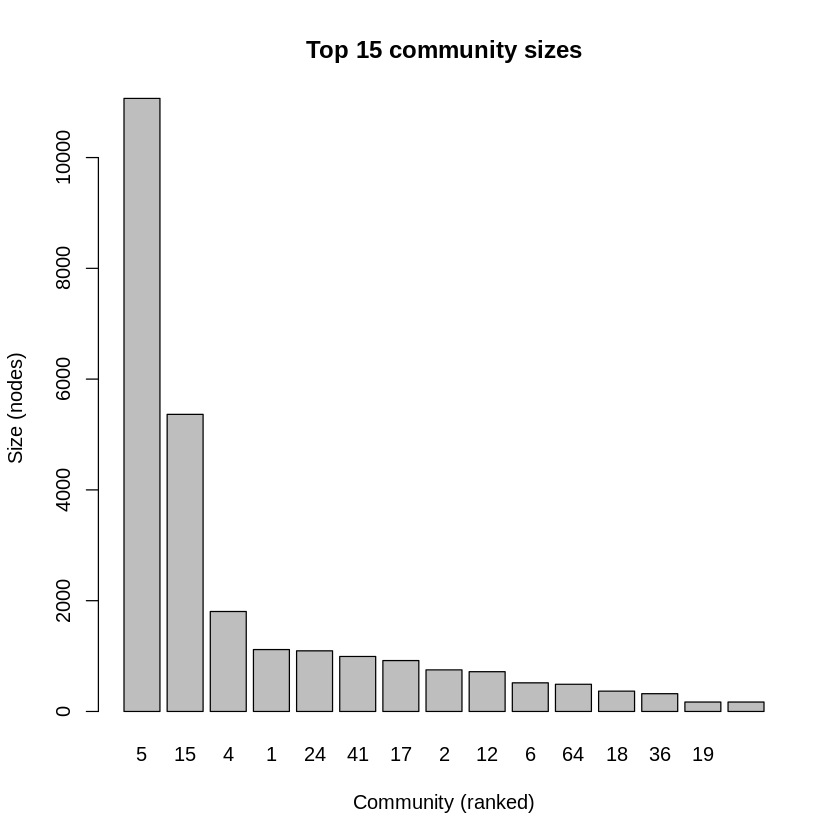

In [10]:
# Barplot of the 15 largest communities
top_k <- 15
sorted_sizes <- sort(comm_sizes, decreasing = TRUE)[1:top_k]

barplot(sorted_sizes,
        main = paste("Top", top_k, "community sizes"),
        xlab = "Community (ranked)",
        ylab = "Size (nodes)")

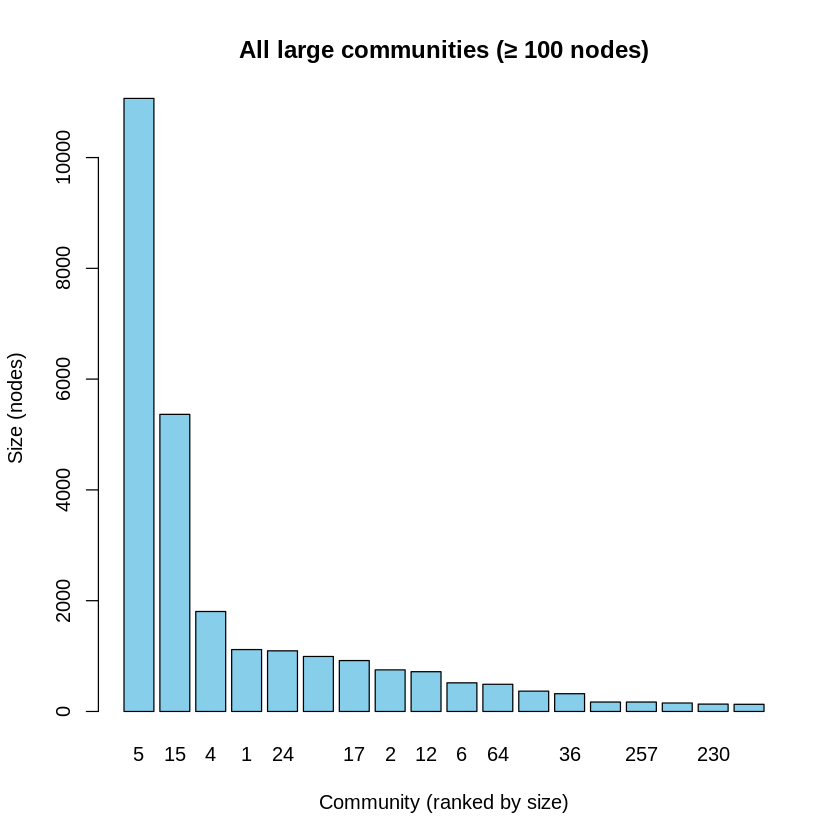

In [13]:
# communities ranked by their size — from largest to smallest.
threshold <- 100
large_sizes <- comm_sizes[comm_sizes >= threshold]
large_sizes <- sort(large_sizes, decreasing = TRUE)
barplot(large_sizes,
        main = paste("All large communities (≥", threshold, "nodes)"),
        xlab = "Community (ranked by size)",
        ylab = "Size (nodes)",
        col = "skyblue")

   rank community_id  size
1     1            5 11068
2     2           15  5364
3     3            4  1805
4     4            1  1118
5     5           24  1095
6     6           41   993
7     7           17   919
8     8            2   751
9     9           12   718
10   10            6   517
11   11           64   491
12   12           18   367
13   13           36   321
14   14           19   170
15   15          257   170
16   16           59   153
17   17          230   133
18   18          120   129


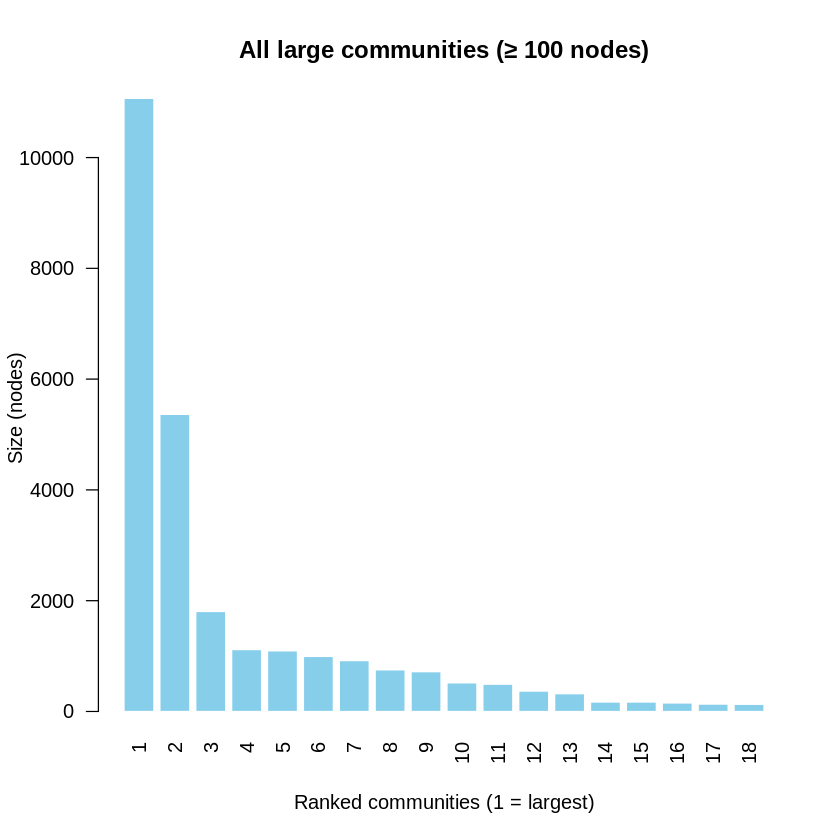

In [14]:
omm_sizes <- sizes(comm)

# 4. Select communities with >= 100 nodes
large_sizes <- comm_sizes[comm_sizes >= 100]

# 5. Sort them in descending order
large_sizes <- sort(large_sizes, decreasing = TRUE)

# 6. Create rank labels (1, 2, 3, ...)
rank_labels <- seq_along(large_sizes)

# 7. Barplot using rank labels
barplot(
  large_sizes,
  main = "All large communities (≥ 100 nodes)",
  xlab = "Ranked communities",
  ylab = "Size (nodes)",
  names.arg = rank_labels,
  col = "skyblue",
  border = "white",
  las = 2
)

# 8. Create a lookup table: rank → actual community ID → size
rank_table <- data.frame(
  rank = rank_labels,
  community_id = names(large_sizes),
  size = as.numeric(large_sizes)
)

print(rank_table)

   rank community_id size
1     1         1272   98
2     2          385   74
3     3           77   70
4     4          245   66
5     5          498   65
6     6          481   60
7     7         1277   55
8     8           90   45
9     9          568   41
10   10         1492   41
11   11         1800   38
12   12          237   37
13   13          739   36
14   14         1819   36
15   15          182   35


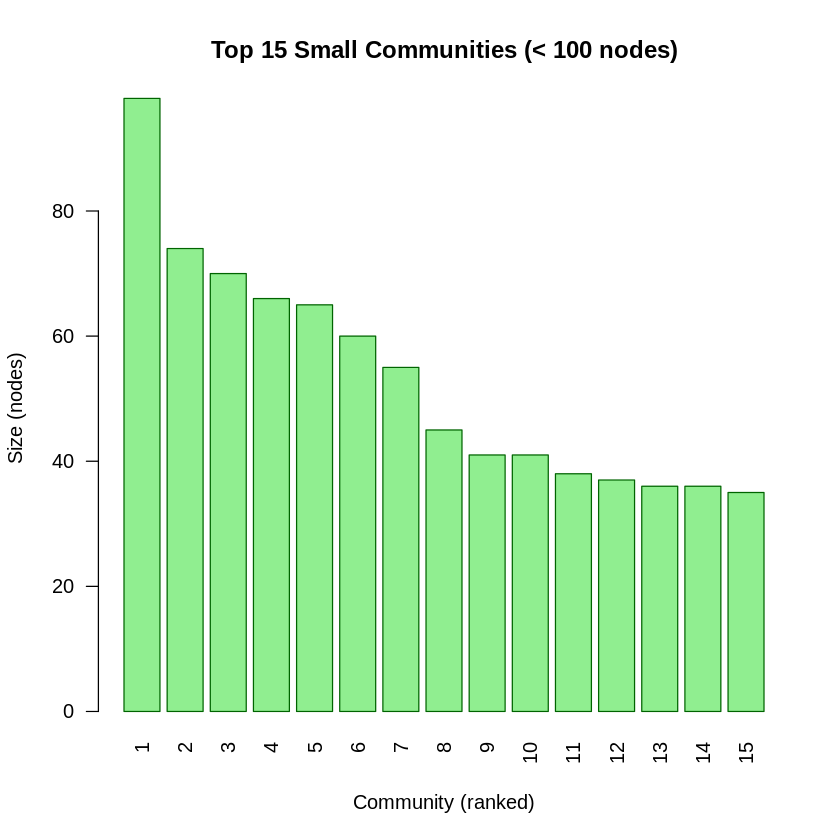

In [15]:


# 2. Community detection (Louvain)
comm <- cluster_louvain(g)

# 3. Community sizes
comm_sizes <- sizes(comm)

# 4. Filter only *small* communities: size < 100
small_comm <- comm_sizes[comm_sizes < 100]

# 5. Take 15 largest among the small ones
top_k <- 15
small_top15 <- sort(small_comm, decreasing = TRUE)[1:top_k]

# 6. Rank labels for clean plot
rank_labels <- seq_along(small_top15)

# 7. Barplot
barplot(
  small_top15,
  main = "Top 15 Small Communities (< 100 nodes)",
  xlab = "Community (ranked)",
  ylab = "Size (nodes)",
  col = "lightgreen",
  border = "darkgreen",
  names.arg = rank_labels,
  las = 2
)

# 8. Lookup table: which community IDs they are
small_table <- data.frame(
  rank = rank_labels,
  community_id = names(small_top15),
  size = as.numeric(small_top15)
)

print(small_table)


## centrality metrics: betweenness, closeness, eigenvector centrality

In [16]:

bet <- betweenness(
  g,
  v          = V(g),    # all nodes
  directed   = FALSE,
  normalized = TRUE
)
bet_df <- data.frame(
  node        = names(bet),
  betweenness = as.numeric(bet)
)


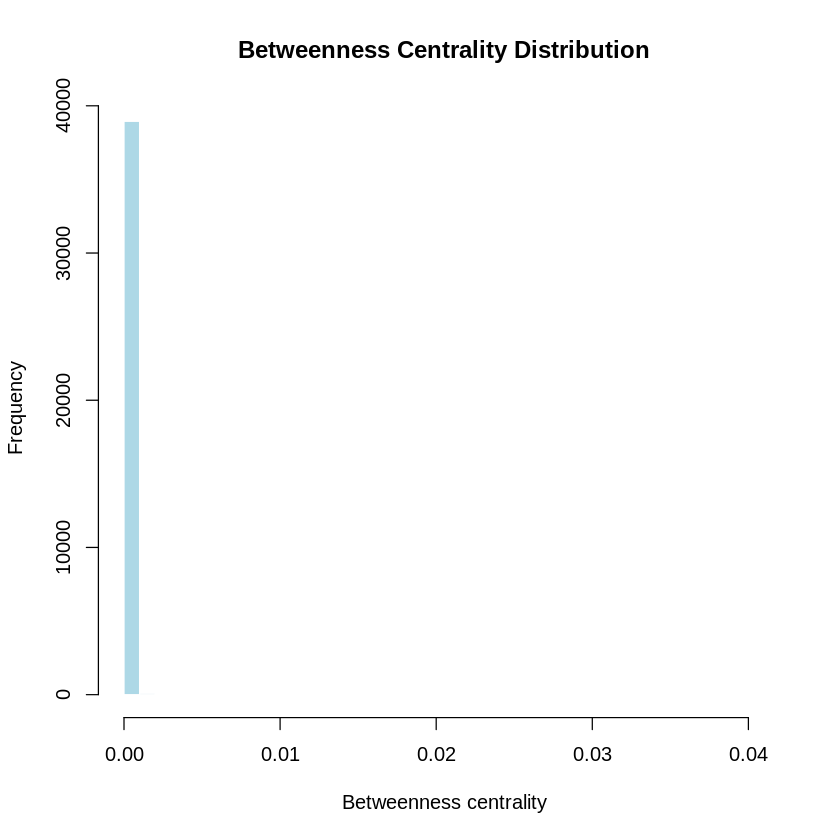

In [17]:
# results from visualisation:almost all betweenness values are extremely close to zero.

hist(
  bet,
  breaks = 50,
  main = "Betweenness Centrality Distribution",
  xlab = "Betweenness centrality",
  col = "lightblue",
  border = "white"
)

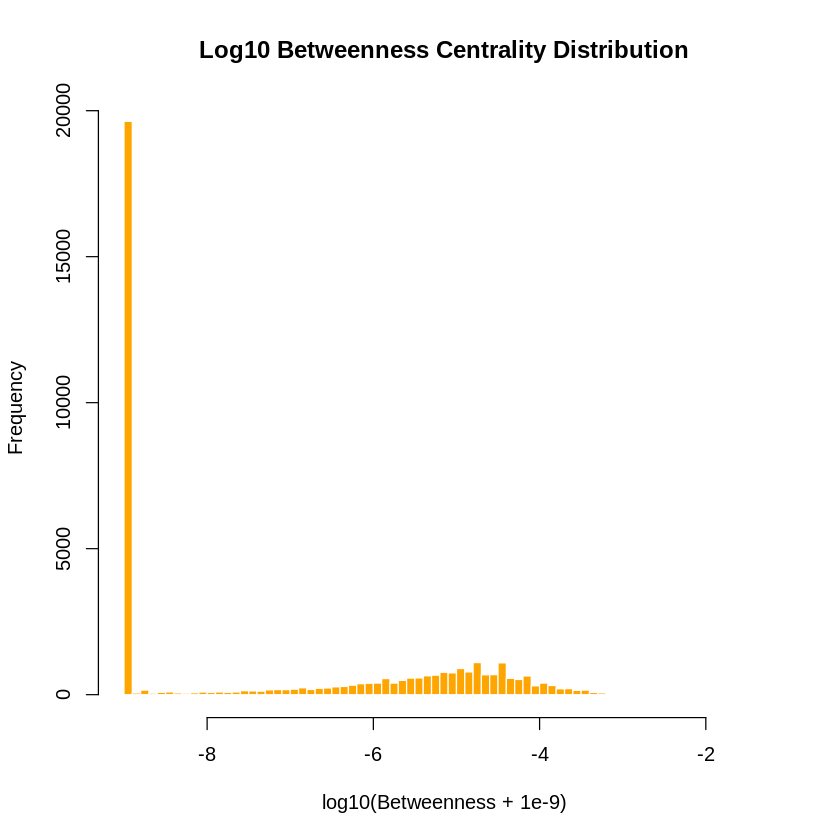

In [19]:
bet_log <- log10(bet + 1e-9)

hist(
  bet_log,
  breaks = 60,
  main = "Log10 Betweenness Centrality Distribution",
  xlab = "log10(Betweenness + 1e-9)",
  col = "orange",
  border = "white"
)


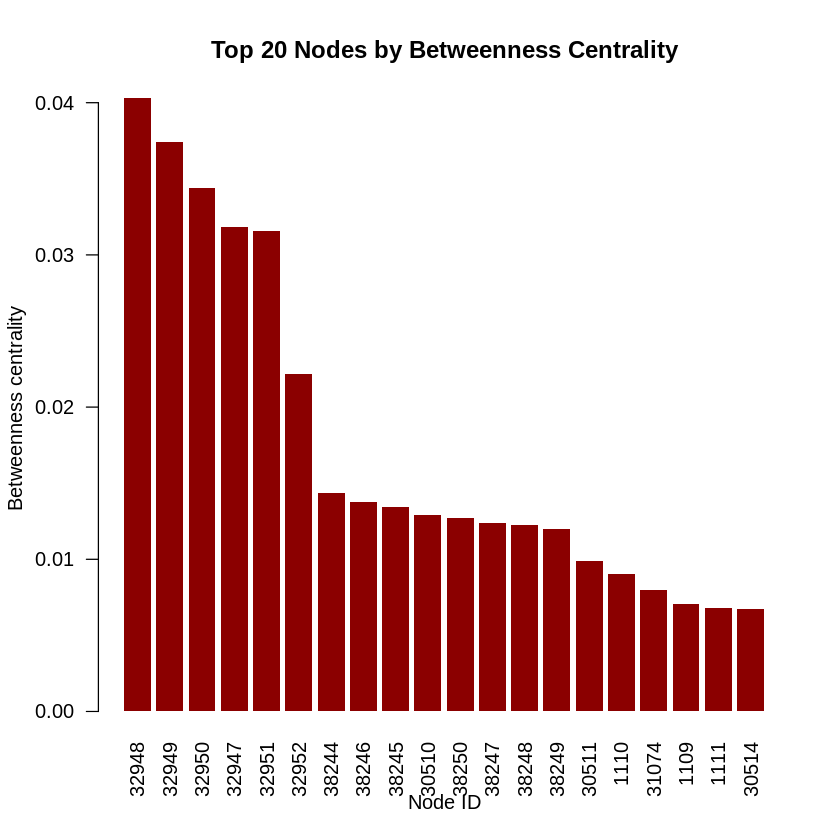

In [18]:
# Sort betweenness and keep top 20
bet_sorted <- sort(bet, decreasing = TRUE)[1:20]

barplot(
  bet_sorted,
  main = "Top 20 Nodes by Betweenness Centrality",
  xlab = "Node ID",
  ylab = "Betweenness centrality",
  col = "darkred",
  border = NA,
  names.arg = names(bet_sorted),
  las = 2
)


In [22]:
# closeness
clo <- closeness(
  g,
  vids       = V(g),
  normalized = TRUE
)

In [23]:
length(clo)


head(clo)

[1] 39086

1         2         4         5         6         7 
0.2144814 0.2144814 0.3806648 0.3806648 0.3805679 0.3805679

In [24]:
clo_df <- data.frame(
  node      = names(clo),
  closeness = as.numeric(clo)
)

head(clo_df)

,node,closeness
,<chr>,<dbl>
1,1,0.2144814
2,2,0.2144814
3,4,0.3806648
4,5,0.3806648
5,6,0.3805679
6,7,0.3805679


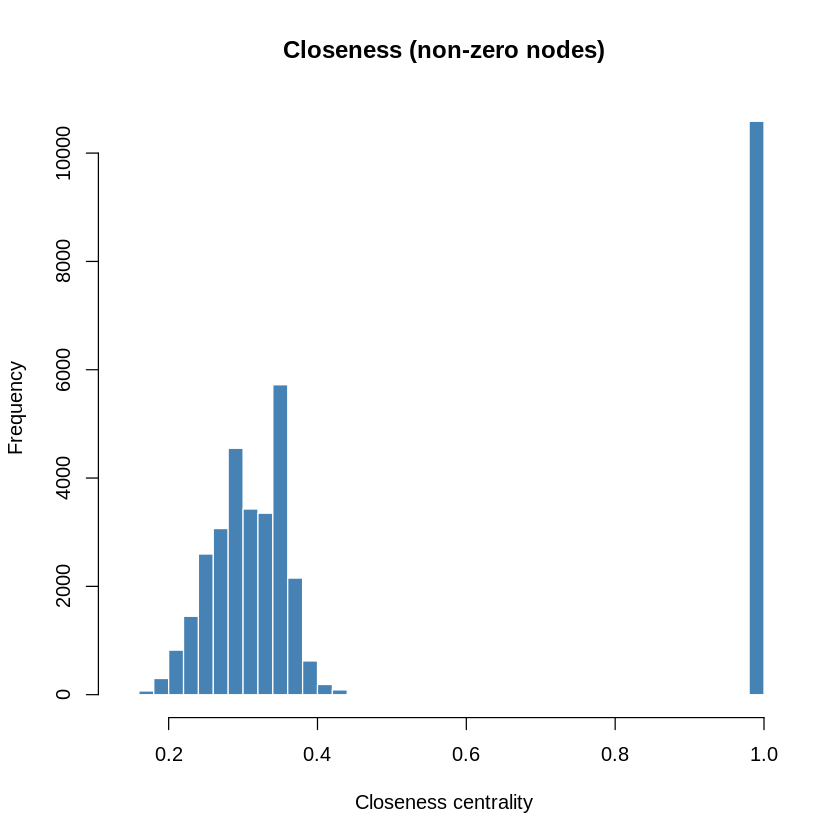

In [25]:
nonzero_clo <- clo[clo > 0]

hist(
  nonzero_clo,
  breaks = 50,
  main = "Closeness (non-zero nodes)",
  xlab  = "Closeness centrality",
  col   = "steelblue",
  border = "white"
)

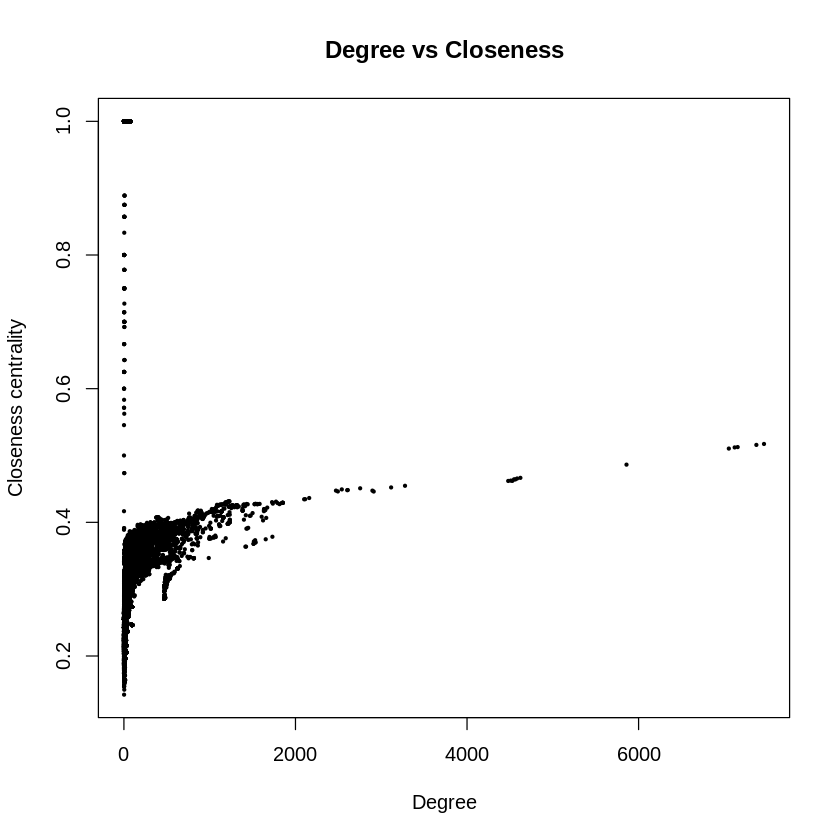

In [31]:
# relationship between degree and closeness centrality
deg <- degree(g)

plot(
  deg, clo,
  xlab = "Degree",
  ylab = "Closeness centrality",
  main = "Degree vs Closeness",
  pch  = 20, cex = 0.5
)

In [32]:
centralization.closeness(g)$centralization


Warning message:
“`centralization.closeness()` was deprecated in igraph 2.0.0.
ℹ Please use `centr_clo()` instead.”


[1] 1.011551

In [26]:
eig_res <- eigen_centrality(
  g,
  directed = FALSE,
  scale    = TRUE   # scale so the maximum eigenvector centrality is 1
)

eig <- eig_res$vector

Warning message:
“The `scale` argument of `eigen_centrality()` is deprecated as of igraph 2.1.1.
ℹ eigen_centrality() will always behave as if scale=TRUE were used.”


In [27]:
length(eig)


head(eig)

[1] 39086

1            2            4            5            6            7 
2.193108e-07 2.193108e-07 1.588310e-01 1.588310e-01 1.587752e-01 1.587752e-01

In [28]:
eig_df <- data.frame(
  node        = names(eig),
  eigenvector = as.numeric(eig)
)

head(eig_df)

,node,eigenvector
,<chr>,<dbl>
1,1,2.193108e-07
2,2,2.193108e-07
3,4,1.588310e-01
4,5,1.588310e-01
5,6,1.587752e-01
6,7,1.587752e-01


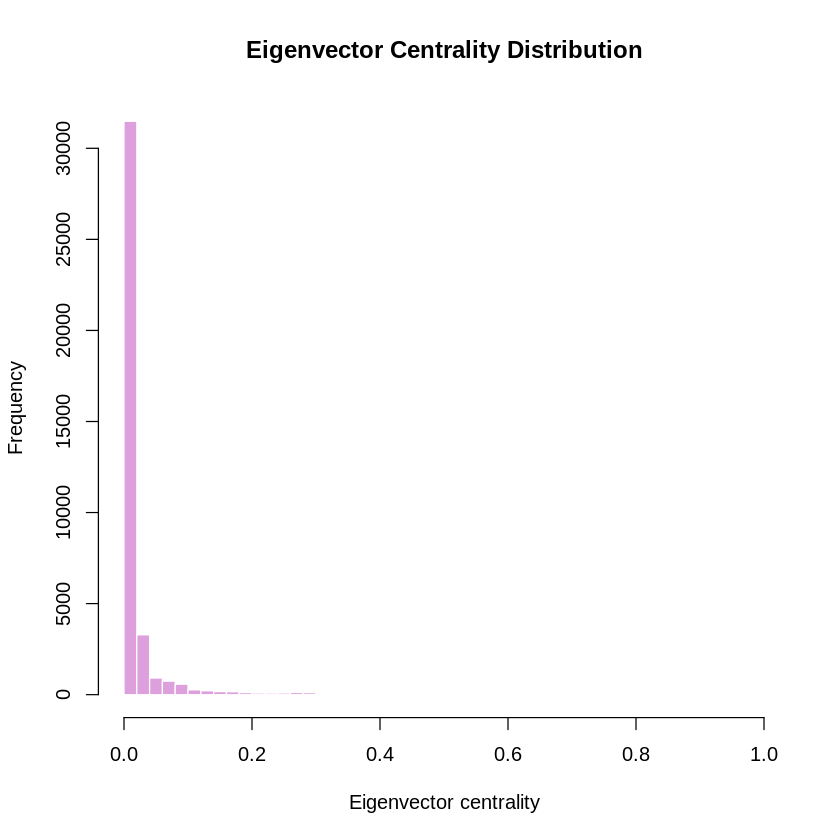

In [33]:
hist(
  eig,
  breaks = 50,
  main = "Eigenvector Centrality Distribution",
  xlab = "Eigenvector centrality",
  col = "plum",
  border = "white"
)

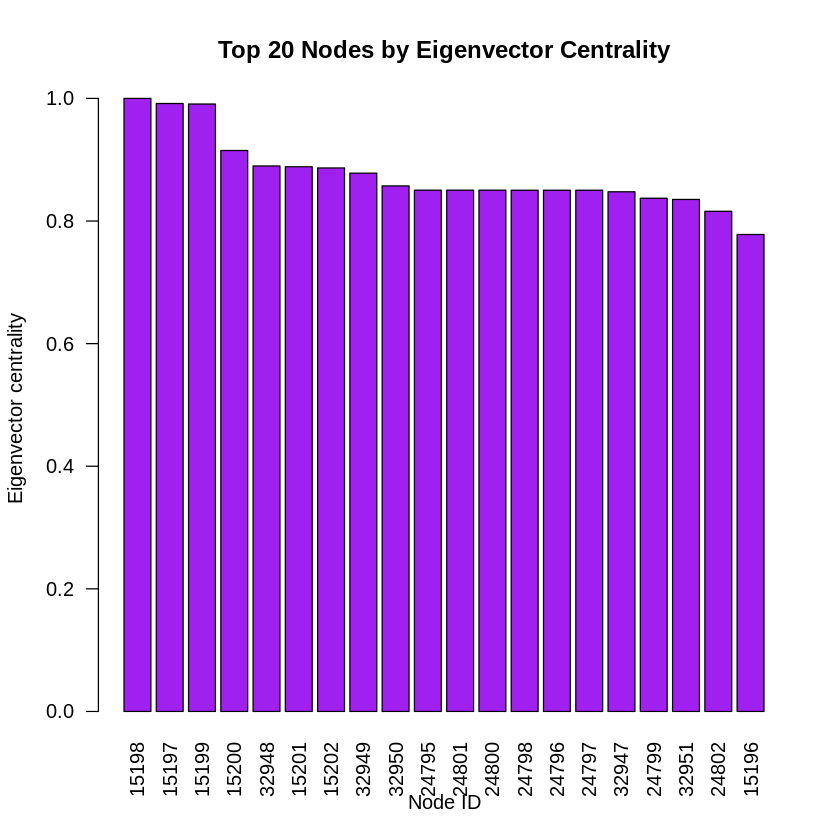

In [34]:
# top 20 most influential nodes
eig_sorted <- sort(eig, decreasing = TRUE)[1:20]

barplot(
  eig_sorted,
  main = "Top 20 Nodes by Eigenvector Centrality",
  xlab = "Node ID",
  ylab = "Eigenvector centrality",
  col  = "purple",
  names.arg = names(eig_sorted),
  las = 2
)

In [29]:
cent_df <- data.frame(
  node        = names(bet),
  betweenness = as.numeric(bet),
  closeness   = as.numeric(clo[names(bet)]),
  eigenvector = as.numeric(eig[names(bet)])
)

head(cent_df)

,node,betweenness,closeness,eigenvector
,<chr>,<dbl>,<dbl>,<dbl>
1,1,1.860633e-05,0.2144814,2.193108e-07
2,2,1.860633e-05,0.2144814,2.193108e-07
3,4,2.917675e-04,0.3806648,1.588310e-01
4,5,2.917675e-04,0.3806648,1.588310e-01
5,6,1.094595e-04,0.3805679,1.587752e-01
6,7,1.094595e-04,0.3805679,1.587752e-01
